## Random Forest Baseline Model

To establish a performance benchmark, we first implement a Random Forest regression model. This model serves as a classical machine learning baseline against which the LSTM model will be compared.

Random Forests are chosen because they:
- Handle nonlinear relationships effectively
- Are robust to noise in real-world sensor data
- Provide strong performance on tabular time-series features without requiring sequence learning

We train separate models for:
- Photovoltaic (PV) generation prediction
- Household energy consumption (grid import)

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor


## Data Preparation

The dataset is first sorted chronologically to preserve temporal order. This is essential for time-series forecasting tasks to prevent information leakage.

We then extract time-based features from the timestamp, including:
- Hour of day
- Day of week
- Month of year

These features provide a basic representation of periodic behavior in energy usage and generation.

In [2]:
df_usage = pd.read_csv("../data/residential3_cleaned.csv")

# Handle timestamp column
if "utc_timestamp" in df_usage.columns:
    df_usage["utc_timestamp"] = pd.to_datetime(df_usage["utc_timestamp"])
    df_usage = df_usage.set_index("utc_timestamp")
else:
    df_usage.iloc[:, 0] = pd.to_datetime(df_usage.iloc[:, 0])
    df_usage = df_usage.set_index(df_usage.columns[0])

df_usage = df_usage.sort_index()

print("Start:", df_usage.index.min())
print("End:", df_usage.index.max())
print("Duration:", df_usage.index.max() - df_usage.index.min())
print("Rows:", len(df_usage))

df_usage.head()

Start: 2016-02-28 17:30:00+00:00
End: 2017-07-08 15:45:00+00:00
Duration: 495 days 22:15:00
Rows: 47610


,DE_KN_residential3_circulation_pump,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_refrigerator,DE_KN_residential3_washing_machine,hour
utc_timestamp,,,,,,,,,
2016-02-28 17:30:00+00:00,0.018,0.001,0.0,0.0,0.145,0.0,0.012,0.0,17
2016-02-28 17:45:00+00:00,0.018,0.000,0.0,0.0,0.180,0.0,0.005,0.0,17
2016-02-28 18:00:00+00:00,0.018,0.001,0.0,0.0,0.180,0.0,0.000,0.0,18
2016-02-28 18:15:00+00:00,0.018,0.001,0.0,0.0,0.238,0.0,0.000,0.0,18
2016-02-28 18:30:00+00:00,0.018,0.000,0.0,0.0,0.230,0.0,0.000,0.0,18


In [3]:
grid_col = "DE_KN_residential3_grid_import"
pv_col = "DE_KN_residential3_pv"

appliance_cols = [
    "DE_KN_residential3_washing_machine",
    "DE_KN_residential3_dishwasher",
    "DE_KN_residential3_freezer",
    "DE_KN_residential3_circulation_pump",
    "DE_KN_residential3_refrigerator"
]

required_cols = [grid_col, pv_col] + appliance_cols

missing_required = [col for col in required_cols if col not in df_usage.columns]

if missing_required:
    raise ValueError(f"Missing columns: {missing_required}")

df_usage = df_usage[required_cols].copy()

Check for extreme values

PV descriptive statistics:
count    47610.000000
mean         0.152820
std          0.793335
min          0.000000
25%          0.000000
50%          0.000000
75%          0.206000
max         73.306000
Name: DE_KN_residential3_pv, dtype: float64

PV quantiles:
0.950     0.701
0.990     0.823
0.999     0.915
1.000    73.306
Name: DE_KN_residential3_pv, dtype: float64


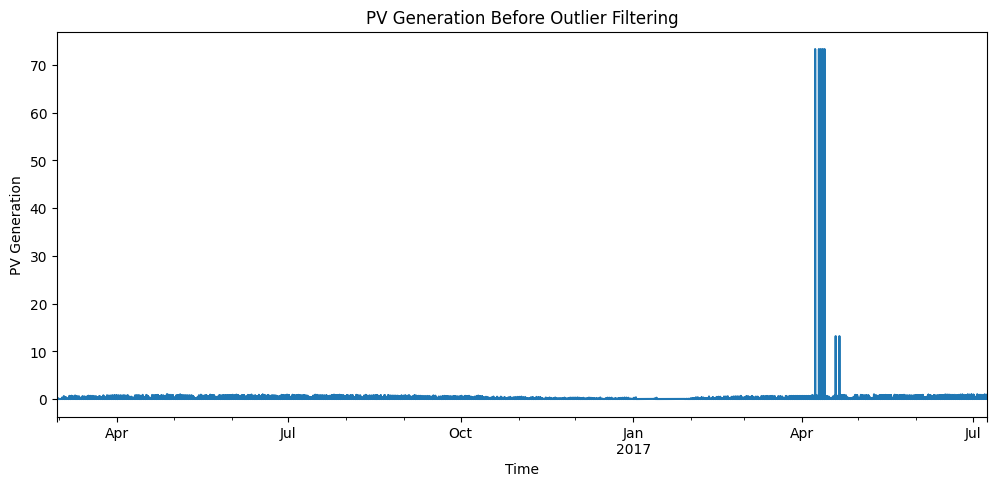

In [4]:
print("PV descriptive statistics:")
print(df_usage[pv_col].describe())

print("\nPV quantiles:")
print(df_usage[pv_col].quantile([0.95, 0.99, 0.999, 1.0]))

plt.figure(figsize=(12, 5))
df_usage[pv_col].plot()
plt.title("PV Generation Before Outlier Filtering")
plt.ylabel("PV Generation")
plt.xlabel("Time")
plt.show()

Remove impossible PV spikes
Based on the EDA, normal 15-minute PV values are below roughly 1.
Values around 70+ are measurement/differencing errors.

In [5]:
pv_outlier_mask = df_usage[pv_col] >= 2

print("Number of PV outliers:", pv_outlier_mask.sum())
display(df_usage.loc[pv_outlier_mask, [pv_col]].head(20))

df_usage = df_usage.copy()

# Replace impossible PV spikes with missing values
df_usage.loc[pv_outlier_mask, pv_col] = np.nan

# Interpolate to keep the 15-minute time index continuous
df_usage[pv_col] = df_usage[pv_col].interpolate(method="time")

# If any NaNs remain at the beginning/end, fill them with 0
df_usage[pv_col] = df_usage[pv_col].fillna(0)

print("PV max after cleaning:", df_usage[pv_col].max())
print("Rows after PV cleaning:", len(df_usage))

Number of PV outliers: 9


,DE_KN_residential3_pv
utc_timestamp,
2017-04-08 01:45:00+00:00,73.305
2017-04-10 01:45:00+00:00,73.305
2017-04-11 01:45:00+00:00,73.305
2017-04-12 01:45:00+00:00,73.306
2017-04-13 01:45:00+00:00,73.305
2017-04-19 00:00:00+00:00,13.176
2017-04-19 00:15:00+00:00,13.177
2017-04-21 00:00:00+00:00,13.176
2017-04-21 00:15:00+00:00,13.177


PV max after cleaning: 0.9890000000004876
Rows after PV cleaning: 47610


## Cyclical Time Feature Encoding

Time variables such as hour and month are inherently cyclical. For example, hour 23 and hour 0 are temporally adjacent, but this relationship is not preserved in raw numerical form.

To address this, we apply sine and cosine transformations:

- This ensures smooth continuity across cycle boundaries
- It prevents artificial discontinuities in the feature space
- It improves model interpretability for periodic patterns

In [6]:
df_model = df_usage.copy()

# Current values
# These are valid because the targets are shifted to t+1.
df_model["pv_current"] = df_model[pv_col]
df_model["cons_current"] = df_model[grid_col]

# Time and seasonality features
df_model["hour_sin"] = np.sin(2 * np.pi * df_model.index.hour / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model.index.hour / 24)

df_model["doy_sin"] = np.sin(2 * np.pi * df_model.index.dayofyear / 365)
df_model["doy_cos"] = np.cos(2 * np.pi * df_model.index.dayofyear / 365)

df_model["month_sin"] = np.sin(2 * np.pi * df_model.index.month / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model.index.month / 12)

df_model["is_weekend"] = (df_model.index.dayofweek >= 5).astype(int)

## Lag Feature Engineering

To capture temporal dependencies in energy consumption and generation, lag features are introduced.

These features represent past observations of:
- PV generation
- Grid import (consumption)

We include multiple time horizons:
- Short-term dependencies (1–4 time steps)
- Medium-term dependencies (12 time steps)
- Long-term dependencies (96–672 time steps)

This allows the model to learn autoregressive behavior in the time series without requiring sequential architectures.

In [7]:
# Time-based features
lags = [1, 4, 12, 96, 672]

for lag in lags:
    df_model[f"cons_lag_{lag}"] = df_model[grid_col].shift(lag)
    df_model[f"pv_lag_{lag}"] = df_model[pv_col].shift(lag)
    
for col in appliance_cols:
    short_name = col.replace("DE_KN_residential3_", "")
    df_model[f"{short_name}_lag_1"] = df_model[col].shift(1)



## Rolling Statistics Feature Engineering

Energy time series data often contains short-term fluctuations and noise. To help the model capture smoother temporal trends, rolling statistics are introduced. Use shift(1) so rolling features only use past observations.


Rolling features summarize recent history of a signal and allow the model to learn:
- Local trends
- Short-term variability
- Smoothed energy consumption and generation patterns

This is especially useful for:
- Capturing gradual changes in household consumption
- Reducing noise in PV generation signals
- Enhancing temporal context for machine learning models

In [8]:
df_model["roll_mean_4"] = df_model[grid_col].shift(1).rolling(4).mean()
df_model["roll_mean_12"] = df_model[grid_col].shift(1).rolling(12).mean()
df_model["roll_mean_96"] = df_model[grid_col].shift(1).rolling(96).mean()

df_model["pv_roll_mean_4"] = df_model[pv_col].shift(1).rolling(4).mean()
df_model["pv_roll_mean_12"] = df_model[pv_col].shift(1).rolling(12).mean()
df_model["pv_roll_mean_96"] = df_model[pv_col].shift(1).rolling(96).mean()

# Handle missing values from rolling window
df_model = df_model.dropna()

## Feature Selection

We construct a multivariate feature set combining:

- Cyclical time features
- Appliance-level energy consumption
- Lagged PV and consumption values

This feature design allows the model to learn both:
- Behavioral energy usage patterns
- Temporal dependencies in past observations

In [9]:
df_model["grid_import_target"] = df_model[grid_col].shift(-1)
df_model["pv_target"] = df_model[pv_col].shift(-1)

# Remove rows created by lags, rolling windows, and shifted targets
df_model = df_model.dropna()

print("Model dataset shape:", df_model.shape)
df_model.head()

Model dataset shape: (46937, 39)


,DE_KN_residential3_grid_import,DE_KN_residential3_pv,DE_KN_residential3_washing_machine,DE_KN_residential3_dishwasher,DE_KN_residential3_freezer,DE_KN_residential3_circulation_pump,DE_KN_residential3_refrigerator,pv_current,cons_current,hour_sin,...,circulation_pump_lag_1,refrigerator_lag_1,roll_mean_4,roll_mean_12,roll_mean_96,pv_roll_mean_4,pv_roll_mean_12,pv_roll_mean_96,grid_import_target,pv_target
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2016-03-06 17:30:00+00:00,0.192,0.0,0.0,0.001,0.0,0.019,0.012,0.0,0.192,-0.965926,...,0.018,0.002,0.13825,0.080083,0.102719,0.0055,0.089583,0.081469,0.170,0.0
2016-03-06 17:45:00+00:00,0.170,0.0,0.0,0.001,0.0,0.018,0.012,0.0,0.170,-0.965926,...,0.019,0.012,0.17625,0.094417,0.102146,0.0025,0.085333,0.081469,0.170,0.0
2016-03-06 18:00:00+00:00,0.170,0.0,0.0,0.000,0.0,0.019,0.011,0.0,0.170,-1.000000,...,0.018,0.012,0.17625,0.108583,0.101187,0.0000,0.071250,0.081469,0.177,0.0
2016-03-06 18:15:00+00:00,0.177,0.0,0.0,0.001,0.0,0.018,0.005,0.0,0.177,-1.000000,...,0.019,0.011,0.18275,0.122750,0.100479,0.0000,0.047583,0.081469,0.175,0.0
2016-03-06 18:30:00+00:00,0.175,0.0,0.0,0.001,0.0,0.019,0.000,0.0,0.175,-1.000000,...,0.018,0.005,0.17725,0.137500,0.099969,0.0000,0.028750,0.081469,0.111,0.0


In [10]:
# Define feature sets


pv_features = [
    # Current PV
    "pv_current",

    # Time and seasonality
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "month_sin",
    "month_cos",
    "is_weekend",

    # PV lag features
    "pv_lag_1",
    "pv_lag_4",
    "pv_lag_12",
    "pv_lag_96",
    "pv_lag_672",

    # PV rolling averages
    "pv_roll_mean_4",
    "pv_roll_mean_12",
    "pv_roll_mean_96"
]

grid_features_no_appliances = [
    # Current grid import
    "cons_current",

    # Time and seasonality
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "month_sin",
    "month_cos",
    "is_weekend",

    # Grid import lag features
    "cons_lag_1",
    "cons_lag_4",
    "cons_lag_12",
    "cons_lag_96",
    "cons_lag_672",

    # Grid import rolling averages
    "roll_mean_4",
    "roll_mean_12",
    "roll_mean_96",

    # PV generation features
    "pv_current",
    "pv_lag_1",
    "pv_lag_4",
    "pv_lag_12",
    "pv_lag_96",
    "pv_lag_672",

    # PV rolling averages
    "pv_roll_mean_4",
    "pv_roll_mean_12",
    "pv_roll_mean_96"
]

grid_features_with_appliances = grid_features_no_appliances + [
    "washing_machine_lag_1",
    "dishwasher_lag_1",
    "freezer_lag_1",
    "circulation_pump_lag_1",
    "refrigerator_lag_1"
]

## Train-Test Split Strategy

To preserve temporal integrity, the dataset is split sequentially rather than randomly.

The first full year of data is used for training, while the remaining future period is used for testing. This preserves chronological order and ensures that the model is evaluated on unseen future observations.

In [11]:
start_date = df_model.index.min()
split_date = start_date + pd.DateOffset(years=1)

train = df_model.loc[df_model.index < split_date]
test = df_model.loc[df_model.index >= split_date]

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())
print("Train rows:", len(train))
print("Test rows:", len(test))

Train period: 2016-03-06 17:30:00+00:00 to 2017-03-06 17:15:00+00:00
Test period: 2017-03-06 17:30:00+00:00 to 2017-07-08 15:30:00+00:00
Train rows: 35040
Test rows: 11897


# Evaluation function and Cross-Validation func

In [12]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [13]:
def time_series_cv_random_forest(data, features, target, model_name, n_splits=3):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_results = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(data), start=1):
        cv_train = data.iloc[train_idx]
        cv_val = data.iloc[val_idx]

        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )

        model.fit(cv_train[features], cv_train[target])
        val_pred = model.predict(cv_val[features])

        result = evaluate_model(
            cv_val[target],
            val_pred,
            f"{model_name} - Fold {fold}"
        )

        result["Fold"] = fold
        cv_results.append(result)

    cv_results_df = pd.DataFrame(cv_results)

    summary = {
        "Model": model_name,
        "Mean MAE": cv_results_df["MAE"].mean(),
        "Std MAE": cv_results_df["MAE"].std(),
        "Mean RMSE": cv_results_df["RMSE"].mean(),
        "Std RMSE": cv_results_df["RMSE"].std(),
        "Mean R2": cv_results_df["R2"].mean(),
        "Std R2": cv_results_df["R2"].std()
    }

    return cv_results_df, summary

In [14]:
def crossfold_feature_importance(
    data,
    features,
    target,
    model_name,
    n_splits=3
):
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_importances = []
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(data), start=1):
        cv_train = data.iloc[train_idx]
        cv_val = data.iloc[val_idx]

        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )

        model.fit(cv_train[features], cv_train[target])

        val_pred = model.predict(cv_val[features])

        mae = mean_absolute_error(cv_val[target], val_pred)
        rmse = np.sqrt(mean_squared_error(cv_val[target], val_pred))
        r2 = r2_score(cv_val[target], val_pred)

        fold_metrics.append({
            "Model": model_name,
            "Fold": fold,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        importance_df = pd.DataFrame({
            "Feature": features,
            "Importance": model.feature_importances_,
            "Fold": fold,
            "Model": model_name
        })

        fold_importances.append(importance_df)

    fold_importance_df = pd.concat(fold_importances, ignore_index=True)
    fold_metrics_df = pd.DataFrame(fold_metrics)

    importance_summary = (
        fold_importance_df
        .groupby("Feature")
        .agg(
            Mean_Importance=("Importance", "mean"),
            Std_Importance=("Importance", "std"),
            Min_Importance=("Importance", "min"),
            Max_Importance=("Importance", "max")
        )
        .sort_values("Mean_Importance", ascending=False)
        .reset_index()
    )

    importance_summary["Model"] = model_name

    return fold_importance_df, importance_summary, fold_metrics_df

## Model Training

Three separate Random Forest regressors are trained:

1. PV generation model
2. Grid import without appliances (consumption) model
3. Grid import with appliances (consumption) model

Random Forest is used as a baseline due to its ability to:
- Capture nonlinear feature interactions
- Perform well on structured tabular data
- Require minimal hyperparameter tuning compared to deep learning models

### Baseline

In [15]:
pv_baseline_pred = test["pv_current"]
grid_baseline_pred = test["cons_current"]

pv_baseline_results = evaluate_model(
    test["pv_target"],
    pv_baseline_pred,
    "Baseline - PV Persistence"
)

grid_baseline_results = evaluate_model(
    test["grid_import_target"],
    grid_baseline_pred,
    "Baseline - Grid Import Persistence"
)

Baseline - PV Persistence
MAE: 0.028554929814243457
RMSE: 0.06184092013554546
R²: 0.9468072264552561

Baseline - Grid Import Persistence
MAE: 0.031399680591740496
RMSE: 0.07270373835977861
R²: 0.5920595514682184



Overall, the baseline results are strong, especially for PV. This means that any machine learning model must outperform a meaningful benchmark, not just produce low error values. The baseline provides a reference point for judging whether Random Forest adds predictive value beyond simple short-term persistence.

### Cross-validation

In [16]:
pv_cv_results, pv_cv_summary = time_series_cv_random_forest(
    data=train,
    features=pv_features,
    target="pv_target",
    model_name="CV - Random Forest PV Generation",
    n_splits=3
)

pv_cv_results

CV - Random Forest PV Generation - Fold 1
MAE: 0.03234722939003902
RMSE: 0.06532662490054693
R²: 0.9400473513506213

CV - Random Forest PV Generation - Fold 2
MAE: 0.015407009565744305
RMSE: 0.03659677620338147
R²: 0.9448733433916057

CV - Random Forest PV Generation - Fold 3
MAE: 0.007057614135320951
RMSE: 0.02094470562277157
R²: 0.9451592036897101



,Model,MAE,RMSE,R2,Fold
0,CV - Random Forest PV Generation - Fold 1,0.032347,0.065327,0.940047,1
1,CV - Random Forest PV Generation - Fold 2,0.015407,0.036597,0.944873,2
2,CV - Random Forest PV Generation - Fold 3,0.007058,0.020945,0.945159,3


In [17]:
grid_no_app_cv_results, grid_no_app_cv_summary = time_series_cv_random_forest(
    data=train,
    features=grid_features_no_appliances,
    target="grid_import_target",
    model_name="CV - Random Forest Grid Import Without Appliances",
    n_splits=3
)

grid_no_app_cv_results

CV - Random Forest Grid Import Without Appliances - Fold 1
MAE: 0.04180760312419985
RMSE: 0.07329426506893975
R²: 0.6098105110819079

CV - Random Forest Grid Import Without Appliances - Fold 2
MAE: 0.04753666700105391
RMSE: 0.08003998520280184
R²: 0.6227027967607941

CV - Random Forest Grid Import Without Appliances - Fold 3
MAE: 0.051007808358066835
RMSE: 0.08570085720425749
R²: 0.6415708710305381



,Model,MAE,RMSE,R2,Fold
0,CV - Random Forest Grid Import Without Applian...,0.041808,0.073294,0.609811,1
1,CV - Random Forest Grid Import Without Applian...,0.047537,0.080040,0.622703,2
2,CV - Random Forest Grid Import Without Applian...,0.051008,0.085701,0.641571,3


In [18]:
grid_app_cv_results, grid_app_cv_summary = time_series_cv_random_forest(
    data=train,
    features=grid_features_with_appliances,
    target="grid_import_target",
    model_name="CV - Random Forest Grid Import With Appliances",
    n_splits=3
)

grid_app_cv_results

CV - Random Forest Grid Import With Appliances - Fold 1
MAE: 0.040723371166177566
RMSE: 0.07184029290833081
R²: 0.6251376997297737

CV - Random Forest Grid Import With Appliances - Fold 2
MAE: 0.04866286734768725
RMSE: 0.07995165056530383
R²: 0.6235351312609227

CV - Random Forest Grid Import With Appliances - Fold 3
MAE: 0.0503022989586401
RMSE: 0.08494222391347073
R²: 0.6478884917005656



,Model,MAE,RMSE,R2,Fold
0,CV - Random Forest Grid Import With Appliances...,0.040723,0.071840,0.625138,1
1,CV - Random Forest Grid Import With Appliances...,0.048663,0.079952,0.623535,2
2,CV - Random Forest Grid Import With Appliances...,0.050302,0.084942,0.647888,3


In [19]:
cv_summary_df = pd.DataFrame([
    pv_cv_summary,
    grid_no_app_cv_summary,
    grid_app_cv_summary
])

cv_summary_df

,Model,Mean MAE,Std MAE,Mean RMSE,Std RMSE,Mean R2,Std R2
0,CV - Random Forest PV Generation,0.018271,0.012886,0.040956,0.022510,0.943360,0.002872
1,CV - Random Forest Grid Import Without Appliances,0.046784,0.004646,0.079678,0.006211,0.624695,0.015974
2,CV - Random Forest Grid Import With Appliances,0.046563,0.005123,0.078911,0.006613,0.632187,0.013621


In [20]:
pv_fold_importance, pv_importance_summary, pv_cv_metrics = crossfold_feature_importance(
    data=train,
    features=pv_features,
    target="pv_target",
    model_name="Random Forest PV Generation",
    n_splits=3
)

grid_app_fold_importance, grid_app_importance_summary, grid_app_cv_metrics = crossfold_feature_importance(
    data=train,
    features=grid_features_with_appliances,
    target="grid_import_target",
    model_name="Random Forest Grid Import With Appliances",
    n_splits=3
)

In [21]:
pv_importance_summary

,Feature,Mean_Importance,Std_Importance,Min_Importance,Max_Importance,Model
0,pv_current,0.950633,0.001642,0.948768,0.951861,Random Forest PV Generation
1,pv_lag_1,0.007423,0.000585,0.006843,0.008012,Random Forest PV Generation
2,hour_sin,0.006147,0.000581,0.005586,0.006746,Random Forest PV Generation
3,pv_roll_mean_4,0.006101,0.000352,0.005855,0.006504,Random Forest PV Generation
4,pv_lag_4,0.005305,0.000188,0.005179,0.005521,Random Forest PV Generation
5,pv_lag_672,0.004134,0.000182,0.004004,0.004342,Random Forest PV Generation
6,pv_lag_96,0.003788,0.000288,0.003459,0.003993,Random Forest PV Generation
7,pv_lag_12,0.003589,0.000303,0.003288,0.003895,Random Forest PV Generation
8,pv_roll_mean_12,0.003577,0.000226,0.003381,0.003825,Random Forest PV Generation
9,pv_roll_mean_96,0.003007,0.000200,0.002782,0.003164,Random Forest PV Generation


In [22]:
grid_app_importance_summary

,Feature,Mean_Importance,Std_Importance,Min_Importance,Max_Importance,Model
0,cons_current,0.709849,0.005798,0.703243,0.714092,Random Forest Grid Import With Appliances
1,hour_sin,0.019370,0.001201,0.018435,0.020724,Random Forest Grid Import With Appliances
2,cons_lag_96,0.017804,0.001897,0.015654,0.019243,Random Forest Grid Import With Appliances
3,cons_lag_1,0.017284,0.001991,0.016124,0.019583,Random Forest Grid Import With Appliances
4,roll_mean_12,0.016094,0.001866,0.014794,0.018233,Random Forest Grid Import With Appliances
5,pv_current,0.016069,0.002241,0.014083,0.018499,Random Forest Grid Import With Appliances
6,roll_mean_96,0.014902,0.001086,0.013760,0.015923,Random Forest Grid Import With Appliances
7,roll_mean_4,0.014297,0.001178,0.013385,0.015627,Random Forest Grid Import With Appliances
8,cons_lag_672,0.013766,0.000725,0.013190,0.014581,Random Forest Grid Import With Appliances
9,pv_roll_mean_96,0.012384,0.000975,0.011296,0.013179,Random Forest Grid Import With Appliances


The PV Random Forest model achieved strong validation performance with a mean R² of 0.94, indicating that short-term PV generation is highly predictable from current PV, lagged PV, and temporal features. For grid import, the model without appliance features achieved a mean R² of 0.625, while the appliance-enhanced model achieved a slightly higher mean R² of 0.632. This suggests that appliance-level features provide some additional predictive value, although most grid-import behavior is already captured by current consumption, lag features, rolling averages, PV generation, and time-based patterns.

# Simplified feature sets

In [23]:
pv_features_simplified = [
    # Current PV
    "pv_current",

    # Time and seasonality
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    # PV lag features
    "pv_lag_1",
    "pv_lag_4",
    "pv_lag_96",
    "pv_lag_672",

    # PV rolling averages
    "pv_roll_mean_4"
]

grid_features_with_appliances_simplified = [
    # Current grid import
    "cons_current",

    # Time and seasonality
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    # Grid import lag features
    "cons_lag_1",
    "cons_lag_4",
    "cons_lag_12",
    "cons_lag_96",
    "cons_lag_672",

    # Grid import rolling averages
    "roll_mean_4",
    "roll_mean_12",
    "roll_mean_96",

    # PV generation features
    "pv_current",
    "pv_lag_1",
    "pv_lag_4",
    "pv_lag_12",
    "pv_lag_96",
    "pv_lag_672",

    # PV rolling averages
    "pv_roll_mean_4",
    "pv_roll_mean_12",
    "pv_roll_mean_96",

    # Appliance lag features
    "freezer_lag_1",
    "circulation_pump_lag_1",
    "washing_machine_lag_1",
    "dishwasher_lag_1",
    "refrigerator_lag_1"
]
grid_features_no_appliances_simplified = [
    # Current grid import
    "cons_current",

    # Time and seasonality
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    # Grid import lag features
    "cons_lag_1",
    "cons_lag_4",
    "cons_lag_12",
    "cons_lag_96",
    "cons_lag_672",

    # Grid import rolling averages
    "roll_mean_4",
    "roll_mean_12",
    "roll_mean_96",

    # PV generation features
    "pv_current",
    "pv_lag_1",
    "pv_lag_4",
    "pv_lag_12",
    "pv_lag_96",
    "pv_lag_672",

    # PV rolling averages
    "pv_roll_mean_4",
    "pv_roll_mean_12",
    "pv_roll_mean_96"
]

# Models with full features

### PV Generation

In [24]:
x_train_pv = train[pv_features]
y_train_pv = train["pv_target"]

x_test_pv = test[pv_features]
y_test_pv = test["pv_target"]

rf_pv = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pv.fit(x_train_pv, y_train_pv)

pv_pred = rf_pv.predict(x_test_pv)

pv_results = evaluate_model(
    y_test_pv,
    pv_pred,
    "Random Forest - PV Generation Prediction"
)

Random Forest - PV Generation Prediction
MAE: 0.024914901842530403
RMSE: 0.05718463117513254
R²: 0.9545159216821199



The PV model achieved strong predictive performance with an R² of 0.955. The persistence baseline was already strong, which is expected for short-term PV forecasting because solar generation changes gradually over consecutive 15-minute intervals. The Random Forest model still improved over the baseline, showing that temporal and historical PV features add useful predictive information.

### Grid import without appliances

In [25]:
x_train_grid_no_app = train[grid_features_no_appliances]
y_train_grid = train["grid_import_target"]

x_test_grid_no_app = test[grid_features_no_appliances]
y_test_grid = test["grid_import_target"]

rf_grid_no_app = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_grid_no_app.fit(x_train_grid_no_app, y_train_grid)

grid_pred_no_app = rf_grid_no_app.predict(x_test_grid_no_app)

grid_no_app_results = evaluate_model(
    y_test_grid,
    grid_pred_no_app,
    "Random Forest - Grid Import Without Appliances"
)

Random Forest - Grid Import Without Appliances
MAE: 0.03472953590082468
RMSE: 0.06672044683989657
R²: 0.656441121373036



For grid import, the persistence baseline achieved a slightly lower MAE, indicating strong short-term continuity in household electricity demand. However, both Random Forest models achieved lower RMSE and higher R², suggesting that they better captured larger fluctuations and explained more of the overall variation in grid import.

### Grid import with appliances

In [26]:
X_train_grid_app = train[grid_features_with_appliances]
X_test_grid_app = test[grid_features_with_appliances]

rf_grid_app = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_grid_app.fit(X_train_grid_app, y_train_grid)

grid_pred_app = rf_grid_app.predict(X_test_grid_app)

grid_app_results = evaluate_model(
    y_test_grid,
    grid_pred_app,
    "Random Forest - Grid Import With Appliances"
)

Random Forest - Grid Import With Appliances
MAE: 0.03512214585654767
RMSE: 0.06666578703161403
R²: 0.6570038025649707



Appliance features provide only marginal additional predictive value, because recent aggregate grid import already captures much of the appliance-driven behavior.

# Models with simplified features

### PV
 

In [27]:
x_train_pv = train[pv_features_simplified ]
y_train_pv = train["pv_target"]

x_test_pv = test[pv_features_simplified ]
y_test_pv = test["pv_target"]

rf_pv_simp = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pv_simp.fit(x_train_pv, y_train_pv)

pv_pred_simp = rf_pv_simp.predict(x_test_pv)

pv_simp_results = evaluate_model(
    y_test_pv,
    pv_pred_simp,
    "Random Forest - Simplified PV Generation Prediction"
)

Random Forest - Simplified PV Generation Prediction
MAE: 0.025031887874913974
RMSE: 0.05745891231255802
R²: 0.9540785543991049



### Grid import no appliance

In [28]:
x_train_grid_no_app = train[grid_features_no_appliances_simplified]
y_train_grid = train["grid_import_target"]

x_test_grid_no_app = test[grid_features_no_appliances_simplified]
y_test_grid = test["grid_import_target"]

rf_grid_no_app_simp = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_grid_no_app_simp.fit(x_train_grid_no_app, y_train_grid)

grid_pred_no_app_simp = rf_grid_no_app_simp.predict(x_test_grid_no_app)

grid_no_app_simp_results = evaluate_model(
    y_test_grid,
    grid_pred_no_app_simp,
    "Random Forest - Simplified Grid Import Without Appliances"
)

Random Forest - Simplified Grid Import Without Appliances
MAE: 0.03466914324523077
RMSE: 0.06663374184101073
R²: 0.6573334690197237



### Import with appliances

In [29]:
X_train_grid_app = train[grid_features_with_appliances_simplified ]
X_test_grid_app = test[grid_features_with_appliances_simplified ]

rf_grid_app_simp = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_grid_app_simp.fit(X_train_grid_app, y_train_grid)

grid_pred_app_simp = rf_grid_app_simp.predict(X_test_grid_app)

grid_app_simp_results = evaluate_model(
    y_test_grid,
    grid_pred_app_simp,
    "Random Forest - Simplified Grid Import With Appliances"
)

Random Forest - Simplified Grid Import With Appliances
MAE: 0.03506341455549005
RMSE: 0.06669022203165831
R²: 0.656752319804875



## Model Evaluation

We evaluate model performance using standard regression metrics:

- MAE (Mean Absolute Error): measures average prediction deviation
- RMSE (Root Mean Squared Error): penalizes large errors more heavily
- R² Score: measures proportion of variance explained by the model

These metrics provide a comprehensive view of both absolute and relative performance.

In [30]:
results_df = pd.DataFrame([
    pv_baseline_results,
    pv_results,
    grid_baseline_results,
    grid_no_app_results,
    grid_app_results,
    pv_simp_results,
    grid_no_app_simp_results,
    grid_app_simp_results
])

results_df

,Model,MAE,RMSE,R2
0,Baseline - PV Persistence,0.028555,0.061841,0.946807
1,Random Forest - PV Generation Prediction,0.024915,0.057185,0.954516
2,Baseline - Grid Import Persistence,0.031400,0.072704,0.592060
3,Random Forest - Grid Import Without Appliances,0.034730,0.066720,0.656441
4,Random Forest - Grid Import With Appliances,0.035122,0.066666,0.657004
5,Random Forest - Simplified PV Generation Predi...,0.025032,0.057459,0.954079
6,Random Forest - Simplified Grid Import Without...,0.034669,0.066634,0.657333
7,Random Forest - Simplified Grid Import With Ap...,0.035063,0.066690,0.656752


PV generation:
Very predictable one step ahead.
Random Forest slightly improves over persistence.

Grid import:
Moderately predictable.
Random Forest improves R² and RMSE over persistence.
Appliance features add only minimal improvement.

Simplified feature sets were tested after cross-fold feature importance analysis on the training period. For PV generation, removing low-importance calendar and redundant lag features caused only a negligible decrease in performance, so the simplified model was retained for interpretability. For grid import, the simplified model without appliance features achieved the best overall performance, indicating that current grid import, historical consumption patterns, PV generation, rolling averages, and time-of-day features captured most of the predictive information. Appliance-level features provided only marginal additional value and were therefore more useful for interpretation than for improving forecasting accuracy.

## Feature Importance Analysis

To better understand how the Random Forest model makes predictions, we analyze feature importance scores.

Feature importance provides insight into which variables contribute most to the model’s decision-making process. This is particularly useful for:
- Interpreting model behavior
- Validating feature engineering choices
- Identifying dominant predictors in the dataset

Simplified PV Model - Feature Importance
pv_current        0.955922
pv_lag_1          0.007484
pv_roll_mean_4    0.006905
pv_lag_4          0.006361
hour_sin          0.005765
pv_lag_672        0.004894
pv_lag_96         0.004881
doy_cos           0.003550
doy_sin           0.003222
hour_cos          0.001016
dtype: float64


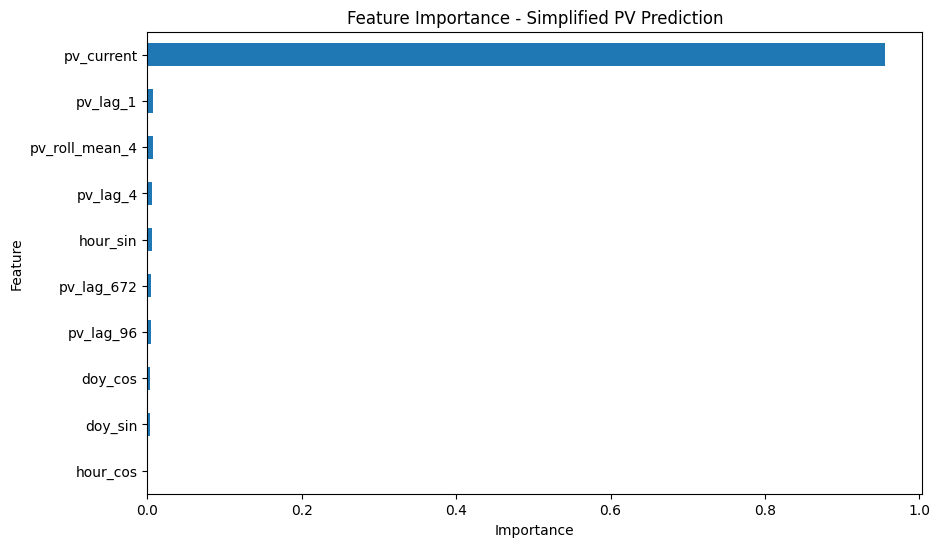

In [31]:
pv_importance_simp = pd.Series(
    rf_pv_simp.feature_importances_,
    index=pv_features_simplified
).sort_values(ascending=False)

print("Simplified PV Model - Feature Importance")
print(pv_importance_simp)

plt.figure(figsize=(10, 6))
pv_importance_simp.sort_values().plot(kind="barh")
plt.title("Feature Importance - Simplified PV Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The PV model was dominated by the current PV generation value, which accounted for most of the feature importance. This is expected for one-step-ahead forecasting, since solar generation usually changes gradually between consecutive 15-minute intervals. Additional contributions came from recent PV lag values, rolling averages, and time-of-day features, while weekend and month indicators had little influence. This suggests that short-term PV prediction is mainly driven by temporal continuity and daylight-related patterns rather than household behavior.

Simplified Grid Import Model Without Appliances - Feature Importance
cons_current       0.715835
cons_lag_1         0.022196
hour_sin           0.019039
roll_mean_96       0.018922
roll_mean_12       0.018623
cons_lag_96        0.018271
roll_mean_4        0.017910
doy_sin            0.017703
cons_lag_672       0.017294
doy_cos            0.014811
cons_lag_12        0.014802
cons_lag_4         0.014650
pv_roll_mean_96    0.014449
pv_current         0.013722
pv_lag_96          0.009262
pv_lag_12          0.008897
pv_roll_mean_12    0.008644
pv_lag_672         0.008611
pv_lag_1           0.007090
pv_roll_mean_4     0.006854
pv_lag_4           0.006425
hour_cos           0.005989
dtype: float64


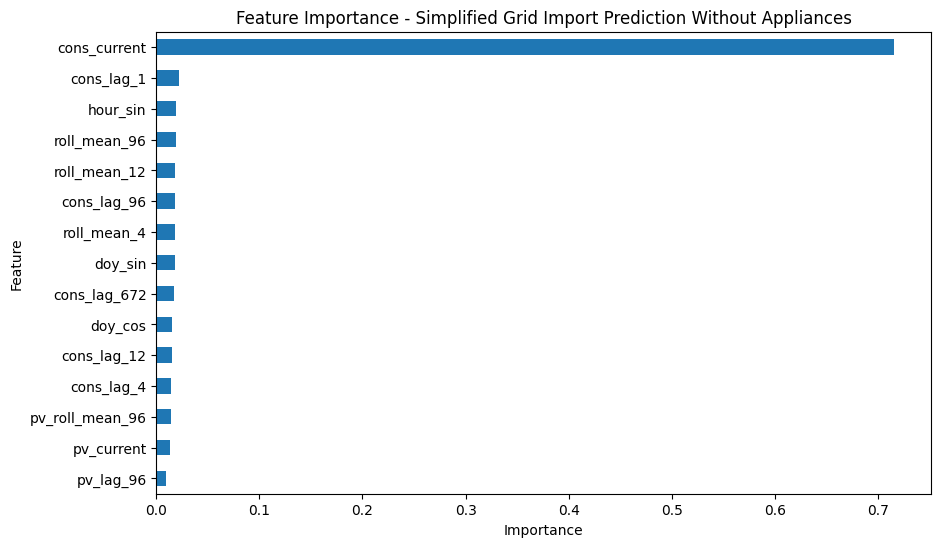

In [36]:
grid_importance_simp = pd.Series(
    rf_grid_no_app_simp.feature_importances_,
    index=grid_features_no_appliances_simplified
).sort_values(ascending=False)

print("Simplified Grid Import Model Without Appliances - Feature Importance")
print(grid_importance_simp)

plt.figure(figsize=(10, 6))
grid_importance_simp.head(15).sort_values().plot(kind="barh")
plt.title("Feature Importance - Simplified Grid Import Prediction Without Appliances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Feature Importance Results

The feature importance analysis reveals which inputs contribute most significantly to the model’s predictive performance.

For the Random Forest model, the most influential features typically include:
- Lagged values of the target variables (especially short-term lags)
- Time-of-day related features
- Appliance-level consumption variables

### Key Observations:
- Lag features are generally the strongest predictors, indicating strong temporal autocorrelation in energy consumption and PV generation.
- Time-based features contribute to capturing daily and seasonal patterns.
- Appliance-level features play a larger role in consumption prediction than in PV generation.

### Interpretation:
This confirms that household energy consumption is highly dependent on recent historical values, while PV generation is less strongly explained by internal household variables.

Plot feature importance

## Feature Importance Visualization

The bar chart below illustrates the top contributing features to the Random Forest model.

This visualization confirms that lagged variables dominate model predictions, reinforcing the importance of temporal dependencies in energy forecasting.

Next we will compare the actual vs the predicted plot to see the model performance

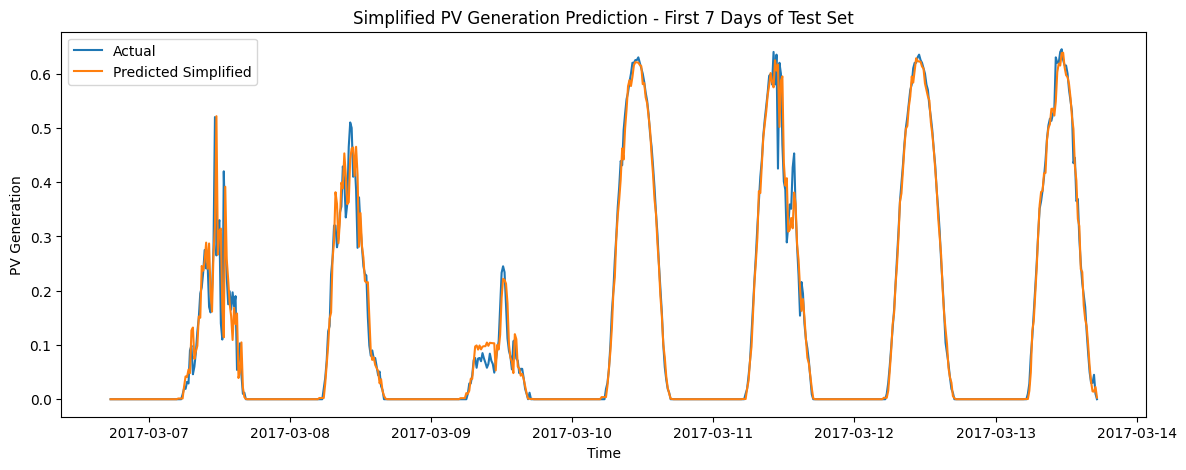

In [35]:
pv_plot = pd.DataFrame({
    "Actual": y_test_pv,
    "Predicted Simplified": pv_pred_simp
}, index=y_test_pv.index)

pv_sample = pv_plot.iloc[:96 * 7]

plt.figure(figsize=(14, 5))
plt.plot(pv_sample.index, pv_sample["Actual"], label="Actual")
plt.plot(pv_sample.index, pv_sample["Predicted Simplified"], label="Predicted Simplified")
plt.title("Simplified PV Generation Prediction - First 7 Days of Test Set")
plt.xlabel("Time")
plt.ylabel("PV Generation")
plt.legend()
plt.show()

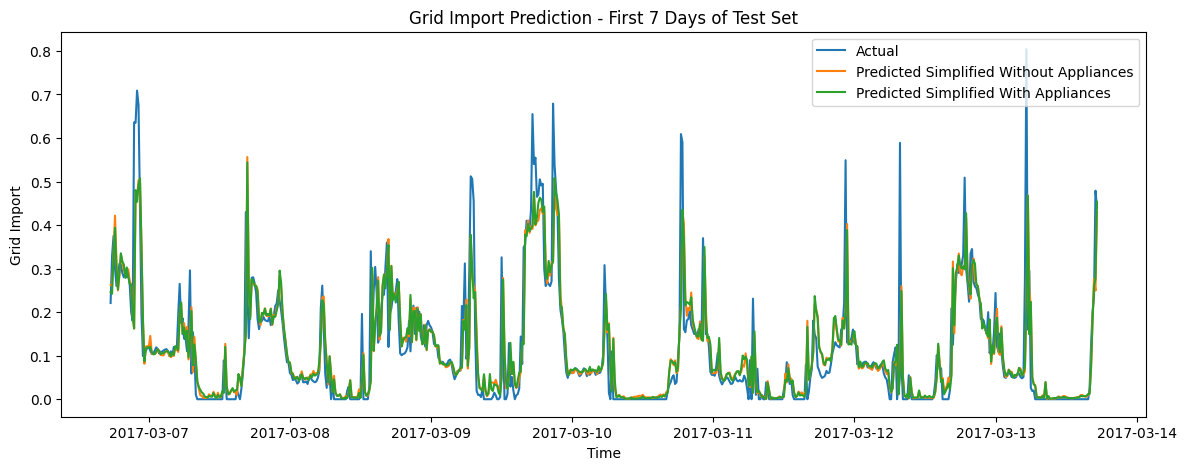

In [34]:
grid_plot = pd.DataFrame({
    "Actual": y_test_grid,
    "Predicted Simplified Without Appliances": grid_pred_no_app_simp,
    "Predicted Simplified With Appliances": grid_pred_app_simp
}, index=y_test_grid.index)

grid_sample = grid_plot.iloc[:96 * 7]

plt.figure(figsize=(14, 5))
plt.plot(grid_sample.index, grid_sample["Actual"], label="Actual")
plt.plot(
    grid_sample.index,
    grid_sample["Predicted Simplified Without Appliances"],
    label="Predicted Simplified Without Appliances"
)
plt.plot(
    grid_sample.index,
    grid_sample["Predicted Simplified With Appliances"],
    label="Predicted Simplified With Appliances"
)
plt.title("Grid Import Prediction - First 7 Days of Test Set")
plt.xlabel("Time")
plt.ylabel("Grid Import")
plt.legend()
plt.show()

PV generation forecasting is fundamentally limited by the absence of exogenous weather-related variables. As a result, even advanced feature engineering (lags, rolling statistics, cyclical encoding) only provides marginal improvements.

Grid import is moderately predictable from current consumption, historical lags, rolling averages, PV generation, and temporal patterns. However, it remains harder to predict than PV because household behavior and appliance usage introduce sudden fluctuations.